In [95]:
%pip install pandas
%pip install seaborn
%pip install matplotlib
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# EDA and Processing 
This section is here to describe and demonstrate the data used to create the anomaly detection

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [97]:
df = pd.read_csv('embedded_system_network_security_dataset.csv')
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [98]:
# Focusing on only a few columns that can be applied to this project
df = df[['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'label', 'mean_packet_size', 'protocol_type_TCP', 'protocol_type_UDP']]

In [99]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   packet_size         1000 non-null   float64
 1   inter_arrival_time  1000 non-null   float64
 2   src_port            1000 non-null   int64  
 3   dst_port            1000 non-null   int64  
 4   label               1000 non-null   float64
 5   mean_packet_size    1000 non-null   float64
 6   protocol_type_TCP   1000 non-null   bool   
 7   protocol_type_UDP   1000 non-null   bool   
dtypes: bool(2), float64(4), int64(2)
memory usage: 49.0 KB
packet_size           0
inter_arrival_time    0
src_port              0
dst_port              0
label                 0
mean_packet_size      0
protocol_type_TCP     0
protocol_type_UDP     0
dtype: int64


In [100]:
print('=== NULL counts ===')
print(df.isnull().sum())

print('\n=== UNIQUE value counts ===')
for col in df.columns:
    n_unique = df[col].nunique()
    print(f'  {col:<30} nunique={n_unique:>6}   dtype={df[col].dtype}')

print('\n=== NUMERIC column stats ===')
num_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[num_cols].describe().T[['mean','std','min','max']])

=== NULL counts ===
packet_size           0
inter_arrival_time    0
src_port              0
dst_port              0
label                 0
mean_packet_size      0
protocol_type_TCP     0
protocol_type_UDP     0
dtype: int64

=== UNIQUE value counts ===
  packet_size                    nunique=   698   dtype=float64
  inter_arrival_time             nunique=  1000   dtype=float64
  src_port                       nunique=   995   dtype=int64
  dst_port                       nunique=     3   dtype=int64
  label                          nunique=     2   dtype=float64
  mean_packet_size               nunique=     1   dtype=float64
  protocol_type_TCP              nunique=     2   dtype=bool
  protocol_type_UDP              nunique=     2   dtype=bool

=== NUMERIC column stats ===


,mean,std,min,max
packet_size,0.502446,0.289606,0.0,1.0
inter_arrival_time,0.512259,0.281130,0.0,1.0
src_port,32024.617000,18520.890349,1038.0,65484.0
dst_port,199.769000,180.078488,53.0,443.0
label,0.100000,0.300150,0.0,1.0
mean_packet_size,0.000000,0.000000,0.0,0.0


In [101]:

# Encode categoricals
cat_cols_to_encode = [c for c in ['protocol_type_TCP', 'protocol_type_UDP'] if c in df.columns]
if cat_cols_to_encode:
    df = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=False)
    print(f'One-hot encoded: {cat_cols_to_encode}')

One-hot encoded: ['protocol_type_TCP', 'protocol_type_UDP']


In [102]:
X_tmp = df.drop(columns=['label'])
y     = df['label'].astype(int)
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns


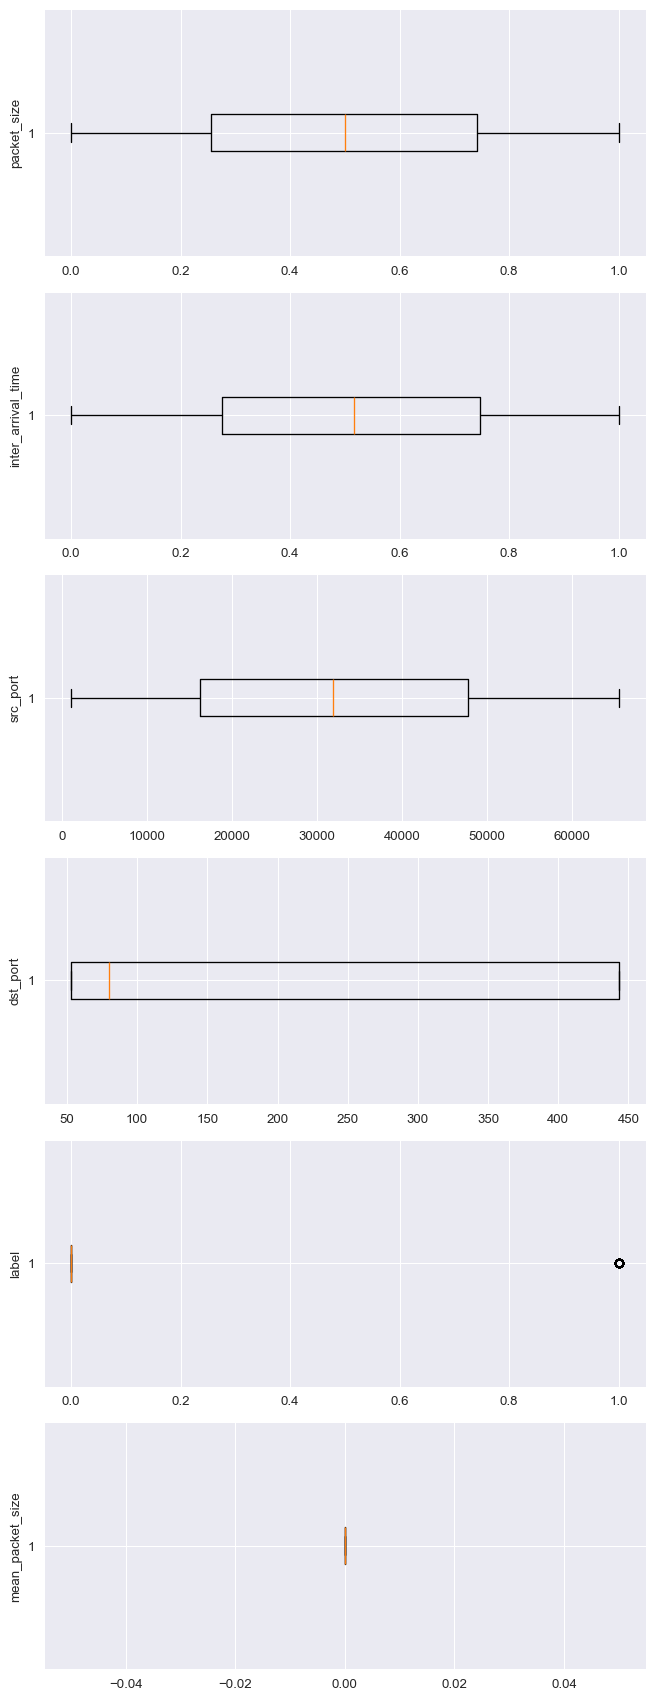

In [103]:
df.describe()

fig, axs = plt.subplots(len(numerical_columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(numerical_columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

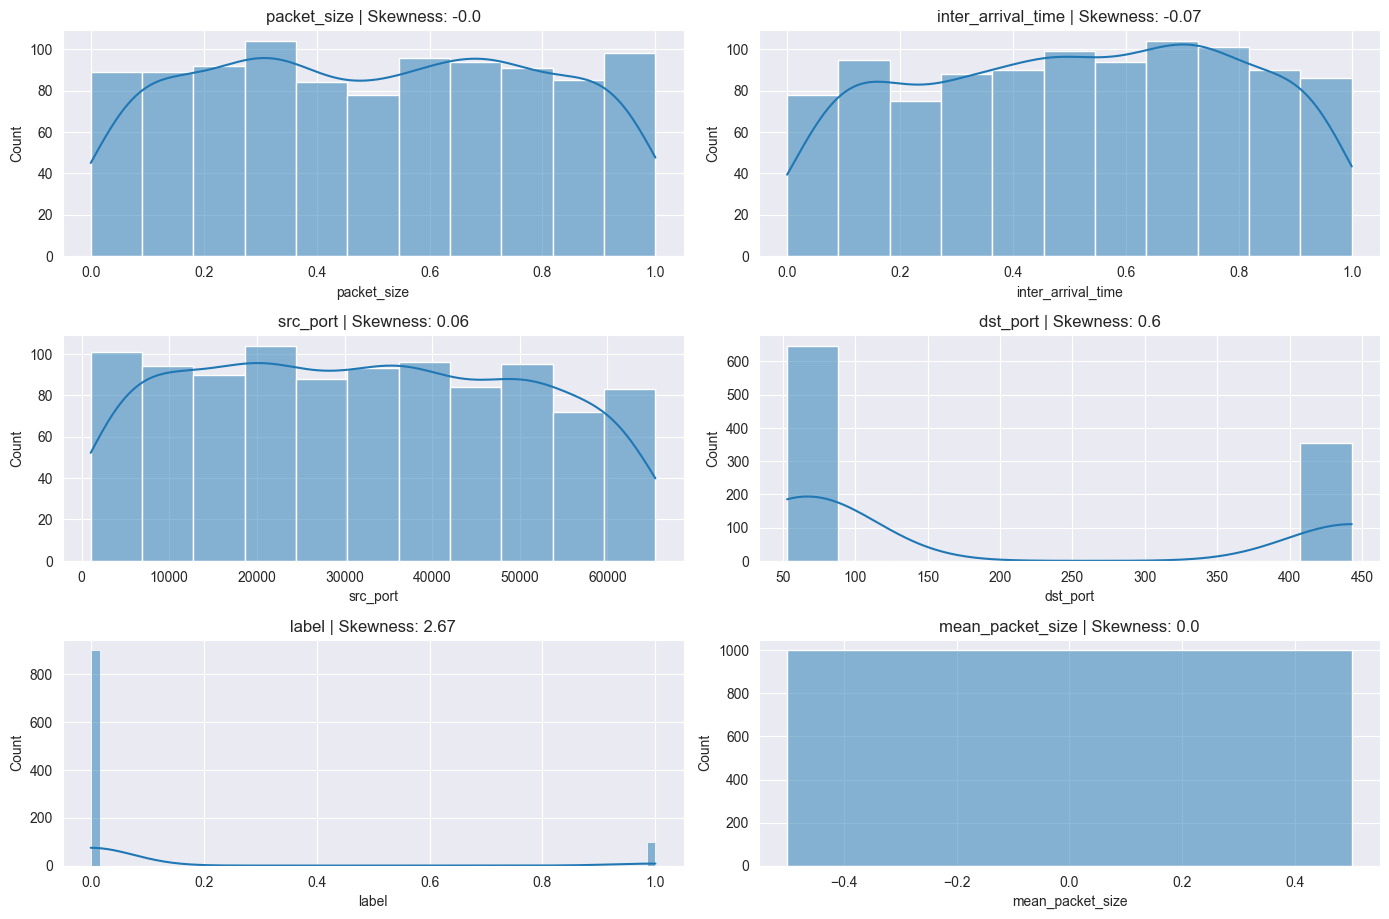

In [104]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

# Feature Selection

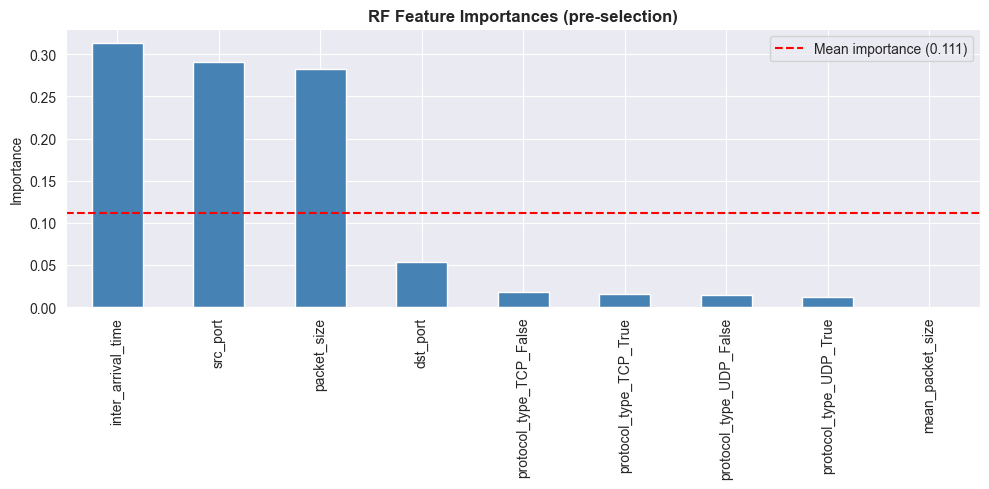

Selected 3 / 9 features:
  inter_arrival_time                  0.3138
  src_port                            0.2913
  packet_size                         0.2821


In [105]:
X = X_tmp.copy()
y = df['label']
SEED = 42
np.random.seed(SEED)
rf_selector = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf_selector.fit(StandardScaler().fit_transform(X), y)

imp = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
imp.plot(kind='bar', color='steelblue')
plt.axhline(imp.mean(), color='red', linestyle='--', label=f'Mean importance ({imp.mean():.3f})')
plt.title('RF Feature Importances (pre-selection)', fontweight='bold')
plt.ylabel('Importance'); plt.legend(); plt.tight_layout(); plt.show()

selected = imp[imp >= imp.mean()].index.tolist()
print(f'Selected {len(selected)} / {len(X.columns)} features:')
for f in selected:
    print(f'  {f:<35} {imp[f]:.4f}')

X = X[selected]

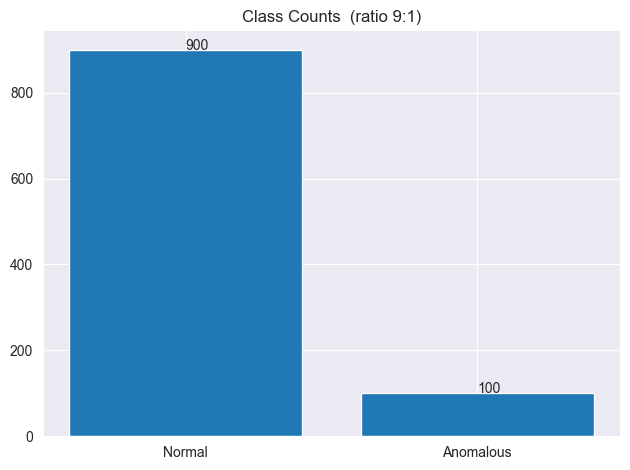

In [106]:
# ─── 7. CLASS BALANCE OVERVIEW ────────────────────────────────────────────────
label_counts = y.value_counts().sort_index()
ratio = label_counts.max() / label_counts.min()
plt.bar(['Normal', 'Anomalous'], label_counts.values)
plt.title(f'Class Counts  (ratio {ratio:.0f}:1)')
for i in range(len(['Normal', 'Anomalous'])):
    plt.text(i, label_counts.values[i], label_counts.values[i]) 
plt.tight_layout(); 
plt.show()



In [107]:
# ─── 8. TRAIN / VAL / TEST SPLIT ──────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print( X_train,'\n', X_test)
print( y_train,'\n', y_test)

     inter_arrival_time  src_port  packet_size
29             0.778455     60793     0.760200
535            0.192935     28837     0.867573
695            0.562417     53509     0.732999
557            0.612502     64819     0.267001
836            0.425060     62481     0.578382
..                  ...       ...          ...
106            0.393809     20350     0.088046
270            0.466975     47097     0.059413
860            0.757617     22736     0.939155
435            0.147497     21152     0.879026
102            0.232430     41953     0.740157

[800 rows x 3 columns] 
      inter_arrival_time  src_port  packet_size
521            0.118377      8258     0.312813
737            0.928721     38410     0.155333
740            0.466218     50558     0.687903
660            0.781494     49095     0.382963
411            0.641126     49325     0.554760
..                  ...       ...          ...
408            0.965784     29736     0.650680
332            0.890394     27998 

In [108]:
# ─── 13. SKLEARN BASELINES ────────────────────────────────────────────────────
# v4: RF with better hyperparameters; XGBoost with dart booster + early stopping

rf = RandomForestClassifier(
    n_estimators=600,
    class_weight='balanced_subsample',  
    max_features='sqrt',
    min_samples_leaf=2,
    max_depth=None,
    random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
print('Random Forest ✓')


xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,          
    max_depth=5,
    min_child_weight=3,          
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    early_stopping_rounds=30,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print(f'XGBoost ✓  (best iteration: {xgb.best_iteration})')

Random Forest ✓
XGBoost ✓  (best iteration: 29)


In [117]:
from sklearn.metrics import accuracy_score
# Make predictions on the test set
y_rf_pred = rf.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_rf_pred)
print("Accuracy:", accuracy)

Accuracy: 0.91


In [118]:
from sklearn.metrics import accuracy_score
# Make predictions on the test set
y_xgb_pred = xgb.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_xgb_pred)
print("Accuracy:", accuracy)

Accuracy: 0.915


In [119]:
from sklearn.model_selection import cross_val_score
# Perform cross-validation
scores = cross_val_score(rf, X, y, cv=5)
# Calculate the average performance across all folds
mean_accuracy = scores.mean()
print("Mean Accuracy:", mean_accuracy)

Mean Accuracy: 0.889


In [120]:
print(classification_report(y_test, y_rf_pred))

print(classification_report(y_test, y_xgb_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95       183
         1.0       0.00      0.00      0.00        17

    accuracy                           0.91       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.84      0.91      0.87       200

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96       183
         1.0       0.00      0.00      0.00        17

    accuracy                           0.92       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.84      0.92      0.87       200



In [127]:
import joblib
saved_model = joblib.dump(xgb, 'xgb_model.pkl')

In [125]:
knn_from_pickle = pickle.loads(saved_model)
knn_from_pickle.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [ ]:
# from scapy.all import get_if_list

# print(get_if_list())

In [133]:
from scapy.all import *

iface = "\\Device\\NPF_Loopback"

packet = IP(dst="127.0.0.2")/TCP(dport=30)/Raw(load="TEST IDS")

send(packet, iface=iface)


Sent 1 packets.


In [ ]:
# from scapy.all import *

# def packet_callback(pkt):
#     print(pkt.summary())

# sniff(iface=iface, prn=packet_callback, store=0)